In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import pickle

In [ ]:
!git clone https://github.com/varaiitj2527/PRMLProject.git
%cd PRMLProject

Cloning into 'PRMLProject'...
remote: Enumerating objects: 53, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (31/31), done.
remote: Total 53 (delta 6), reused 15 (delta 0), pack-reused 18 (from 2)
Receiving objects: 100% (53/53), 163.15 MiB | 15.76 MiB/s, done.
Resolving deltas: 100% (6/6), done.
Updating files: 100% (26/26), done.
Filtering content: 100% (12/12), 851.90 MiB | 64.49 MiB/s, done.
/content/PRMLProject


In [ ]:
def unpickle(file):
    with open(file, 'rb') as f:
        return pickle.load(f)

In [ ]:
X_train_knn_Hog=unpickle("PreProcessedData/TrainFeaturesHoG.pkl")
print(X_train_knn_Hog.shape)
y_train=unpickle("PreProcessedData/Labels_train.pkl")
print(y_train.shape)
X_test_knn_Hog=unpickle("PreProcessedData/TestFeaturesHoG.pkl")
y_test=unpickle("PreProcessedData/Labels_test.pkl")

(50000, 324)
(50000,)


In [ ]:
# Flattening the image
X_train_knn_Hog = X_train_knn_Hog.reshape(50000, -1)
X_test_knn_Hog = X_test_knn_Hog.reshape(10000, -1)

print(X_train_knn_Hog.shape)
print(X_test_knn_Hog.shape)

(50000, 324)
(10000, 324)


Writing our own KNN Implementation

In [ ]:
import numpy as np
from collections import Counter
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

def find_knn(k=6, X_train=X_train_knn_Hog, X_test=X_test_knn_Hog, y_train=y_train, y_test=y_test):
    correct = 0
    results = []

    for idx, test_sample in enumerate(tqdm(X_test)):
        # Computing distances in a vectorized way
        distances = np.linalg.norm(X_train - test_sample, axis=1)

        # Getting indices of k smallest distances
        k_nearest_indices = np.argsort(distances)[:k]

        # Getting labels of k nearest neighbors
        k_labels = y_train[k_nearest_indices]

        # Majority vote for classification
        predicted_label = Counter(k_labels).most_common(1)[0][0]
        results.append(predicted_label)

        # Accuracy calculation
        if predicted_label == y_test[idx]:
            correct += 1

    accuracy = correct / len(X_test)
    print(f"Accuracy: {accuracy:.4f}")

    # Computing confusion matrix
    conf_matrix = confusion_matrix(y_test, results)
    print("Confusion Matrix:\n", conf_matrix)

    # Plotting confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=range(10), yticklabels=range(10))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

    return results, accuracy


100%|██████████| 10000/10000 [09:08<00:00, 18.25it/s]


Accuracy: 0.5263
Confusion Matrix:
 [[503  24  64  13 116  16  66  34 140  24]
 [  9 717   9   1  40   4  87   5  41  87]
 [ 29  11 385  24 204  63 220  27  21  16]
 [  8  24  54 150 266  95 309  40  10  44]
 [ 10   9  47  20 624  20 203  42   7  18]
 [  0   2  45  67 220 288 286  54  12  26]
 [  5  12  31  12  70  20 834   2   8   6]
 [  1  12  36  25 190  55 118 523   8  32]
 [ 55  95  24   4  70   8  64  13 583  84]
 [ 12  70  12  15  86   9  69  27  44 656]]


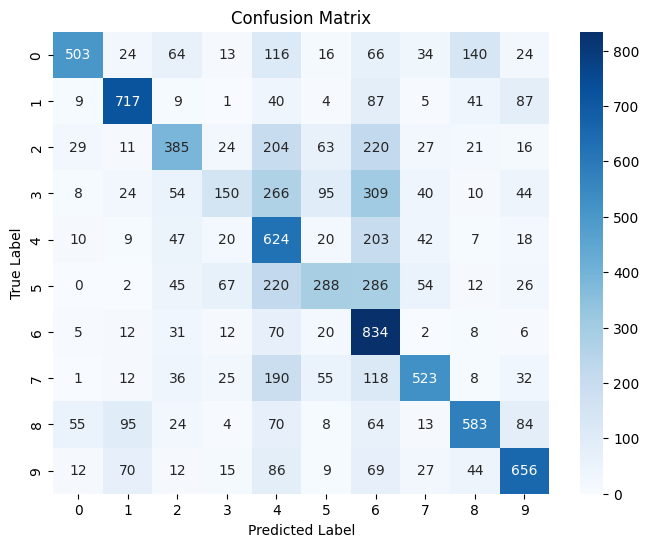

In [ ]:
results,accuracy = find_knn()

In [ ]:

accuracy

0.5263

using SkLearn Library with Euclidean as the distance metric

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def find_knn1(k=6, X_train=X_train_knn_Hog, X_test=X_test_knn_Hog, y_train=y_train, y_test=y_test):
    # Initialize k-NN classifier
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')

    # Train the model
    knn.fit(X_train, y_train)

    # Predict on test data
    y_pred = knn.predict(X_test)

    # Compute accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy:.4f}")

    # Compute confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:\n", conf_matrix)

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=range(10), yticklabels=range(10))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

    return accuracy


Accuracy: 0.5274
Confusion Matrix:
 [[545  27  72  15 126  12  49  16 120  18]
 [ 14 758   7   1  46   4  86   3  28  53]
 [ 40  13 425  32 207  52 190  14  19   8]
 [ 15  30  81 191 268  93 262  19   5  36]
 [ 17  15  65  29 653  11 168  25   5  12]
 [  4  13  68  99 248 266 243  39   3  17]
 [  6  14  44  16  86  21 804   1   6   2]
 [  2  14  64  36 215  47 108 480   6  28]
 [ 84 113  32   4  83   8  49  12 556  59]
 [ 20  93  26  17  99   7  79  22  41 596]]


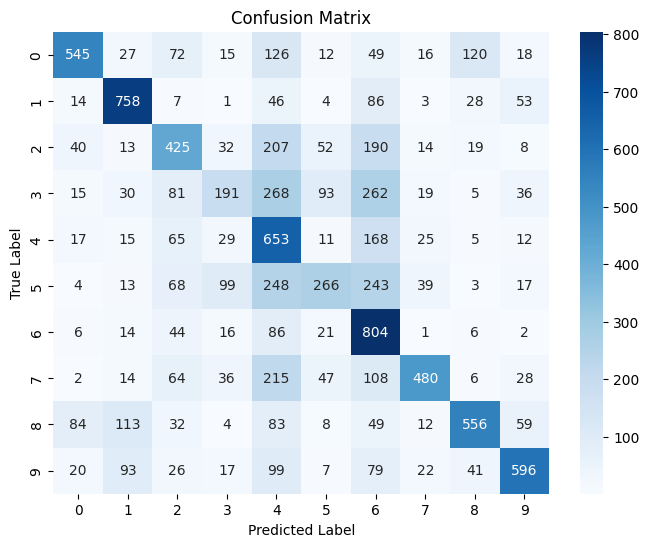

0.5274

In [ ]:
find_knn1()

using SkLearn Library with Manhattan as the distance metric

Accuracy: 0.5627
Confusion Matrix:
 [[632  32  67  15  59  11  33  18 115  18]
 [ 25 788   7   3  31   4  37   5  48  52]
 [ 63  16 467  41 157  63 131  24  28  10]
 [ 30  44  91 213 200 117 200  43  18  44]
 [ 31  19  73  36 614  26 130  47   8  16]
 [ 10  23  83 111 171 347 169  53  11  22]
 [ 10  23  41  26  78  32 766   5  11   8]
 [ 17  21  61  46 144  60  65 553   5  28]
 [114  94  24   6  36   8  24   9 629  56]
 [ 31 115  18  15  82   8  45  21  47 618]]


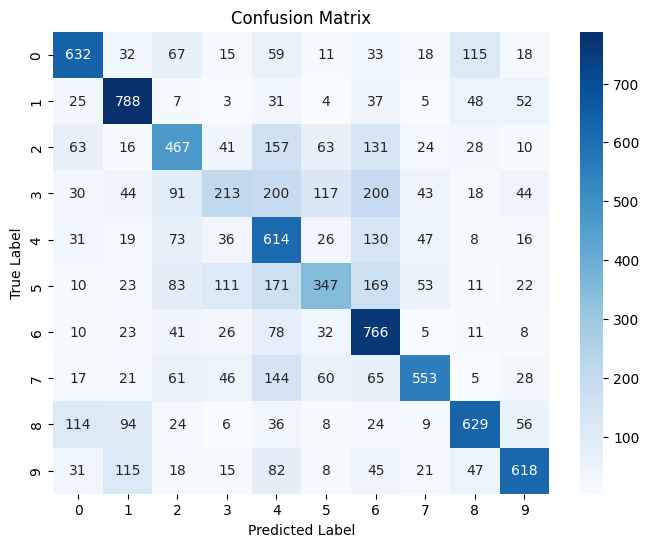

0.5627


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def find_knn2(k=6, X_train=X_train_knn_Hog, X_test=X_test_knn_Hog, y_train=y_train, y_test=y_test):
    # Initialize k-NN classifier with Manhattan distance
    knn = KNeighborsClassifier(n_neighbors=k, metric='manhattan')

    # Train the model
    knn.fit(X_train, y_train)

    # Predict on test data
    y_pred = knn.predict(X_test)

    # Compute accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy:.4f}")

    # Compute confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:\n", conf_matrix)

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=range(10), yticklabels=range(10))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

    return accuracy

accuracy = find_knn2()
print(accuracy)


using SkLearn Library with Canberra as the distance metric

Accuracy: 0.4163
Confusion Matrix:
 [[428  59  73  19 152  22  91  24  91  41]
 [ 19 548  15  12  80   0 213  15  29  69]
 [ 42  13 321  38 219  67 263  15  10  12]
 [  6  30  86 141 290  61 336  16   9  25]
 [ 10   8  71  26 578  12 268  18   2   7]
 [  3   5  64  96 281 193 308  34   5  11]
 [  3   7  38  15  85  13 826   4   2   7]
 [  6   9  57  31 338  44 182 313   2  18]
 [ 86 127  48  14 137  13 100  22 394  59]
 [ 18  71  32  13 194  13 194  15  29 421]]


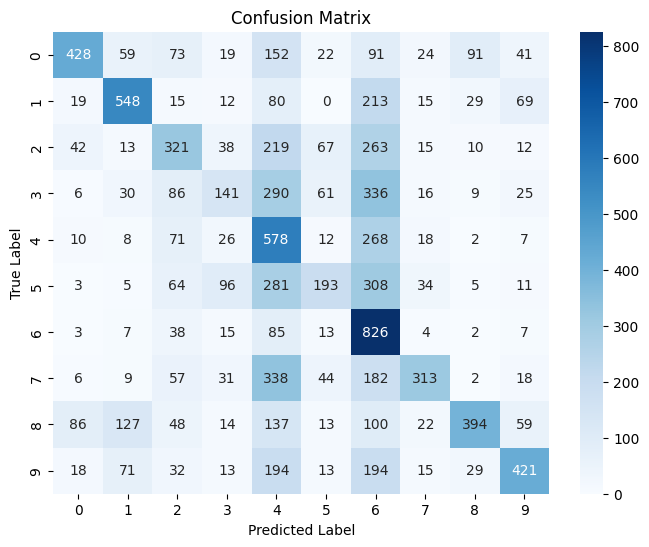

0.4163


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def find_knn3(k=6, X_train=X_train_knn_Hog, X_test=X_test_knn_Hog, y_train=y_train, y_test=y_test):
    # Initialize k-NN classifier with Canberra distance metric
    knn = KNeighborsClassifier(n_neighbors=k, metric='canberra')

    # Train the model
    knn.fit(X_train, y_train)

    # Predict on test data
    y_pred = knn.predict(X_test)

    # Compute accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy:.4f}")

    # Compute confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:\n", conf_matrix)

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=range(10), yticklabels=range(10))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

    return accuracy

accuracy = find_knn3()
print(accuracy)


using SkLearn Library with Bray Curtis as the distance metric

Accuracy: 0.5254
Confusion Matrix:
 [[546  41  71  12 111  15  50  26 103  25]
 [ 15 749  10   5  41   2  76   7  29  66]
 [ 36  14 420  42 199  60 193  13  15   8]
 [ 12  35  68 187 256 107 262  33   9  31]
 [ 16  13  59  34 634  19 169  38   4  14]
 [  4  13  67  90 226 282 243  55   5  15]
 [  3  17  41  15  74  20 814   3   5   8]
 [  8  18  64  37 203  57 107 474   6  26]
 [ 79 121  29   6  65  11  53  17 546  73]
 [ 16  95  19  15 113   4  72  24  40 602]]


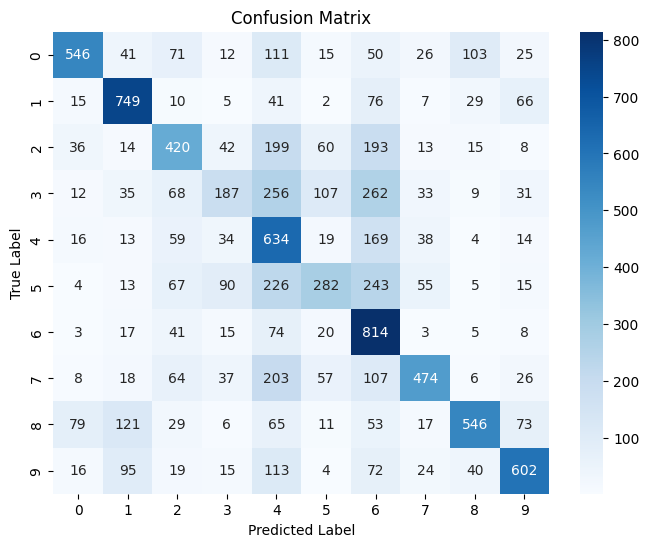

0.5254

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def find_knn4(k=6, X_train=X_train_knn_Hog, X_test=X_test_knn_Hog, y_train=y_train, y_test=y_test):
    # Initialize k-NN classifier with Bray-Curtis distance metric
    knn = KNeighborsClassifier(n_neighbors=k, metric='braycurtis')

    # Train the model
    knn.fit(X_train, y_train)

    # Predict on test data
    y_pred = knn.predict(X_test)

    # Compute accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy:.4f}")

    # Compute confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:\n", conf_matrix)

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=range(10), yticklabels=range(10))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

    return accuracy

find_knn4()
